# Compare configurations

Each run is auto-labelled by **only what varies between runs** (the configuration tokens it
actually differs on). Everything is saved under `results/<sample>/<TITLE>/<date>/`.

In [1]:
TITLE     = "Jun23_config_sweep"            # results/<date>/<TITLE>/ ...
DATA_ROOT = "data/Jun23"                    # day folder holding the per-config run folders (switch to today, e.g. data/Jun23, once acquired)
COMPARISON_VARIABLE = "Configuration"
SORT_KEY  = "config"                        # 'config' | 'time' | 'power' | 'angle' | 'name'

In [2]:
try:
    import ipympl  # noqa: F401
    get_ipython().run_line_magic('matplotlib', 'widget')
    print('Interactive backend: ipympl (drag to zoom)')
except (ImportError, AttributeError):
    get_ipython().run_line_magic('matplotlib', 'inline')
    print('Fallback backend: inline (ipympl not installed)')
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src" / "core.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
RESULTS_DIR = ROOT / "results"
print("Project root:", ROOT)

Project root: /Users/simon.wtmn/Desktop/Quantum_SHHG


## 1. Discover the configuration runs

In [3]:
from src.report import discover_runs, AnalysisReport

runs = discover_runs(ROOT / DATA_ROOT, sort_key=SORT_KEY)
print(f"Found {len(runs)} run(s):")
for r in runs:
    print(f"  - {r.run_dir.name:28s} | {r.legend_tag()}")

Found 0 run(s):


## 2. Overlay + save

Builds and **saves** the overlaid grid for each observable under
`results/<sample>/<TITLE>/<date>/{coherence,g2,R}/`. Comment out any observable you don't need;
set `singles=True` to also save one overlaid figure per pair.

In [4]:
rep = AnalysisReport(runs, title=TITLE, results_root=RESULTS_DIR, comparison_variable=COMPARISON_VARIABLE)

rep.coherence(xlim=150, singles=False, show_singles=False)
rep.g2(methods=["direct"], tau_min=0.3, tau_max=40, step=1.0, singles=False, show_singles=False)
rep.R(methods=["direct"], tau_min=0.3, tau_max=40, step=1.0, singles=False, show_singles=False)

ValueError: No runs to analyse.

## 3. Per-pair comparisons (optional)

Uncomment to also save one overlaid figure per detector pair.

In [ ]:
# rep.coherence(xlim=150, singles=True, grid=False, show_singles=False)
# rep.g2(methods=["direct"], singles=True, grid=False, show_singles=False)
# rep.R(methods=["direct"], singles=True, grid=False, show_singles=False)

## 4. Quick zoom

Drag on any figure above to zoom, or re-render one pair with explicit `xlim` / `ylim`.

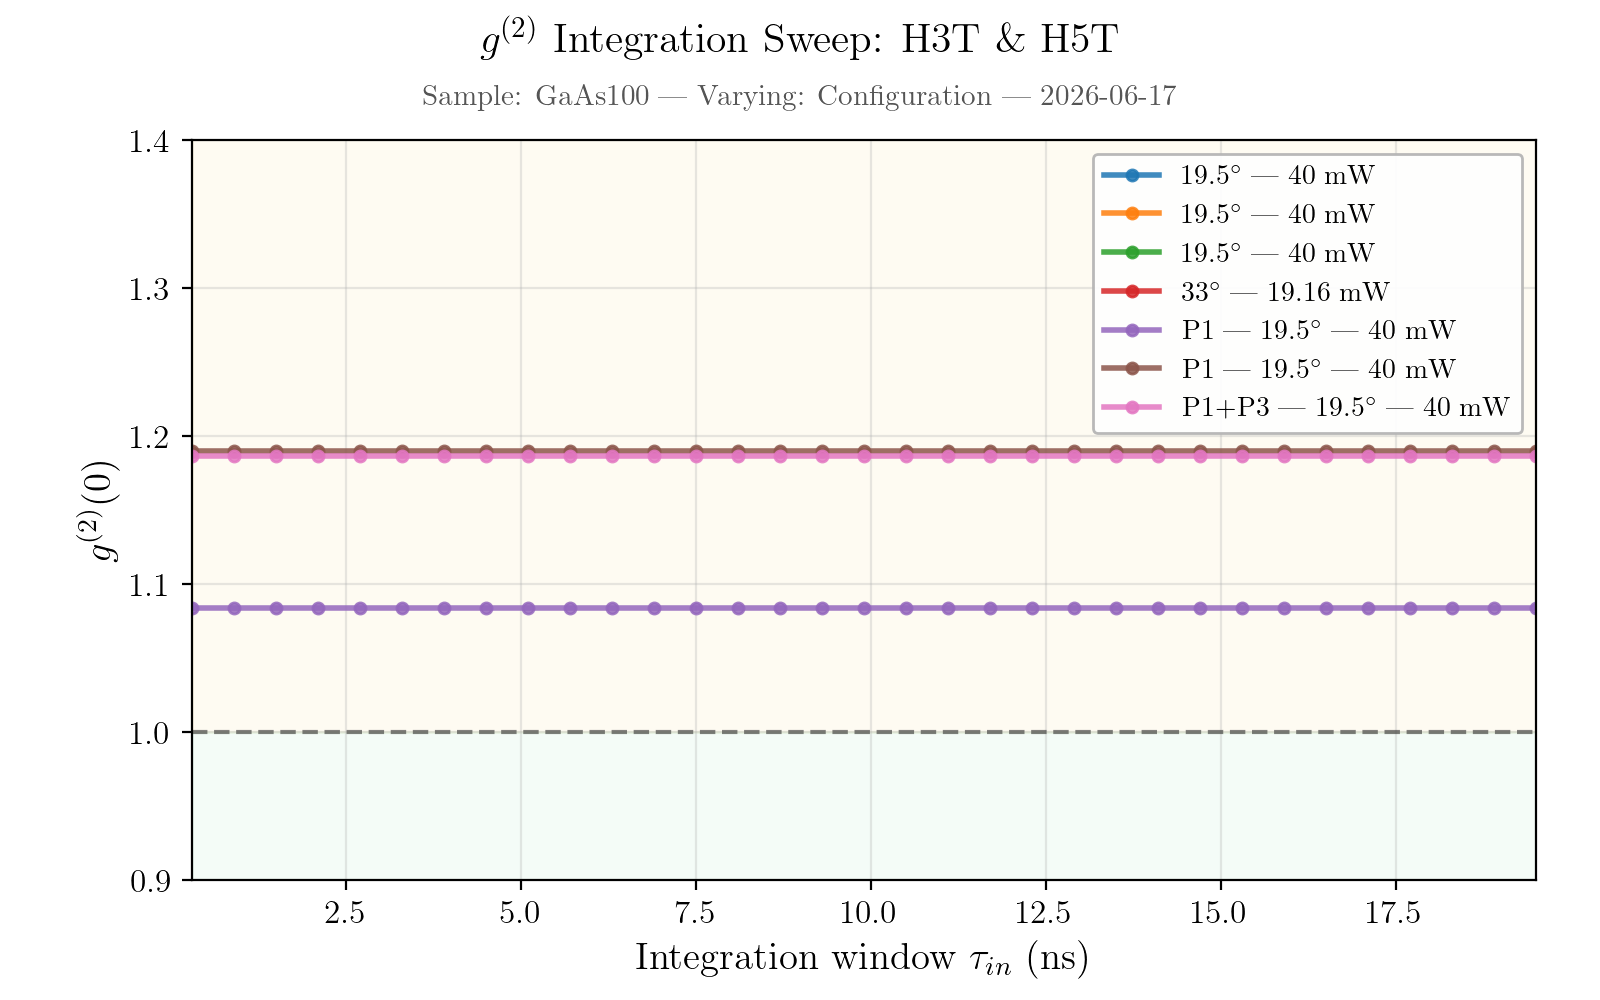

In [ ]:
ref = rep.runs[0]
fig, ax = rep.visu.plot_g2(ref.get_ch("H3T"), ref.get_ch("H5T"), methods=["direct"],
                           tau_min=0.3, tau_max=20, step=0.6, ylim=(0.9, 1.4))
rep._display(fig)